In [2]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split

In [3]:
import os

# Oyaage Kaggle username saha key eka methanata danna
os.environ['KAGGLE_USERNAME'] = "devindithathsara "
os.environ['KAGGLE_KEY'] = "29219555"

print("⏳ Downloading dataset from Kaggle...")
!pip install -q kaggle
!kaggle datasets download -d mlg-ulb/creditcardfraud
!unzip -o creditcardfraud.zip -d dataset/

import pandas as pd
from sklearn.preprocessing import StandardScaler

print("⏳ Loading and preprocessing dataset...")
df = pd.read_csv('dataset/creditcard.csv')

# scalling time and amount (anith ewa kalinma PCA walin scale wela thiyenne)
scaler = StandardScaler()
df['scaled_amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1,1))
df['scaled_time'] = scaler.fit_transform(df['Time'].values.reshape(-1,1))

#remove old features
df.drop(['Time', 'Amount'], axis=1, inplace=True)

# X (features) saha y (labels) widihata wen kirima
X = df.drop('Class', axis=1).values
y = df['Class'].values

print(f"✅ Dataset ready! Total transactions: {len(df)}")

⏳ Downloading dataset from Kaggle...
Dataset URL: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
License(s): DbCL-1.0
100% 66.0M/66.0M [00:00<00:00, 128MB/s]

Archive:  creditcardfraud.zip
  inflating: dataset/creditcard.csv  
⏳ Loading and preprocessing dataset...
✅ Dataset ready! Total transactions: 284807


In [4]:
from sklearn.model_selection import StratifiedKFold, train_test_split

NUM_CLIENTS = 12

skf = StratifiedKFold(n_splits=NUM_CLIENTS, shuffle=True, random_state=42)

clients_final_data = {}
client_id = 0

print("⏳ Distributing data to 12 banks...")

⏳ Distributing data to 12 banks...


In [5]:
for train_idx, client_idx in skf.split(X, y):
    X_client = X[client_idx]
    y_client = y[client_idx]

    # for each bank; local data train (80%) , test (20%)
    X_train, X_test, y_train, y_test = train_test_split(
        X_client, y_client, test_size=0.2, random_state=42, stratify=y_client
    )

    # RAM eka ithuru karaganna float32 widihata save kirima
    clients_final_data[client_id] = {
        "X_train": np.array(X_train, dtype='float32'),
        "y_train": np.array(y_train, dtype='float32'),
        "X_test": np.array(X_test, dtype='float32'),
        "y_test": np.array(y_test, dtype='float32')
    }
    client_id += 1

print("✅ Data distributed successfully!\n")

✅ Data distributed successfully!



In [6]:
# check data(bankuwakata bedila tyn data gaana)
for i in range(NUM_CLIENTS):
    total = len(clients_final_data[i]['y_train']) + len(clients_final_data[i]['y_test'])
    frauds = int(sum(clients_final_data[i]['y_train']) + sum(clients_final_data[i]['y_test']))
    print(f"🏦 Bank {i+1}: Total Transactions = {total} | Frauds = {frauds}")

🏦 Bank 1: Total Transactions = 23734 | Frauds = 41
🏦 Bank 2: Total Transactions = 23734 | Frauds = 41
🏦 Bank 3: Total Transactions = 23734 | Frauds = 41
🏦 Bank 4: Total Transactions = 23734 | Frauds = 41
🏦 Bank 5: Total Transactions = 23734 | Frauds = 41
🏦 Bank 6: Total Transactions = 23734 | Frauds = 41
🏦 Bank 7: Total Transactions = 23734 | Frauds = 41
🏦 Bank 8: Total Transactions = 23734 | Frauds = 41
🏦 Bank 9: Total Transactions = 23734 | Frauds = 41
🏦 Bank 10: Total Transactions = 23734 | Frauds = 41
🏦 Bank 11: Total Transactions = 23734 | Frauds = 41
🏦 Bank 12: Total Transactions = 23733 | Frauds = 41


In [7]:
import tensorflow as tf
from tensorflow.keras import layers, models

# create Model function
# මෙහි විශේෂත්වය වන්නේ BatchNormalization layers ඇතුළත් කිරීමයි (FedBN සඳහා)
def create_model():
    model = models.Sequential([
        layers.Input(shape=(30,)), # Features 30 (V1-V28 + Scaled Time + Scaled Amount)
        layers.Dense(32, activation='relu'),
        layers.BatchNormalization(), # FedBN වලදී මේ layer එක share කරන්නේ නැහැ
        layers.Dropout(0.2),

        layers.Dense(16, activation='relu'),
        layers.BatchNormalization(), # FedBN වලදී මේ layer එක share කරන්නේ නැහැ

        layers.Dense(1, activation='sigmoid') # Binary Classification (Fraud or Not)
    ])

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

In [8]:
# create Global Models සහ Local Client Models
print("⏳ Creating models for 12 banks...")

# FedAvg
global_fedavg_model = create_model()

# FedBN
global_fedbn_model = create_model()

# බැංකු 12 සඳහා Local Models (FedBN වලදී මේවා මතකයේ තබා ගත යුතුයි)
client_models = [create_model() for _ in range(NUM_CLIENTS)]

⏳ Creating models for 12 banks...


In [9]:
# give same  Weights
initial_weights = global_fedbn_model.get_weights()
for model in client_models:
    model.set_weights(initial_weights)

print("✅ Global and Local Models are created and initialized.")

✅ Global and Local Models are created and initialized.


In [10]:
import gc

# Training Parameters
NUM_ROUNDS = 20
LOCAL_EPOCHS = 1
BATCH_SIZE = 32

fedbn_history = []

print("🚀 Starting Corrected Federated Training Loop (FedBN)...")

for round_num in range(NUM_ROUNDS):
    print(f"--- Global Round {round_num+1}/{NUM_ROUNDS} ---")

    # 1. සියලුම බැංකු වල weights තාවකාලිකව තබා ගැනීමට ලැයිස්තුවක්
    all_client_layer_weights = []

    # --- Local Training for each Bank ---
    for client_id in range(NUM_CLIENTS):
        X_train = clients_final_data[client_id]["X_train"]
        y_train = clients_final_data[client_id]["y_train"]

        local_model = client_models[client_id]

        # දත්ත ප්‍රමාණය අනුව fit කිරීම
        local_model.fit(X_train, y_train, epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE, verbose=0)

        # හැම layer එකකම weights වෙන වෙනම list එකකට ගන්න
        weights_per_layer = [layer.get_weights() for layer in local_model.layers]
        all_client_layer_weights.append(weights_per_layer)

    # --- FedBN Aggregation (Layer by Layer) ---
    for i, layer in enumerate(global_fedbn_model.layers):
        # Layer එකේ weights තියෙනවා නම් සහ එය BatchNormalization නොවේ නම් පමණක් එකතු කරන්න
        if len(layer.get_weights()) > 0 and not isinstance(layer, tf.keras.layers.BatchNormalization):
            # සියලුම clients ගේ i-වැනි layer එකේ weights ලබා ගැනීම
            layer_weights_all_clients = [cw[i] for cw in all_client_layer_weights]

            # Kernel සහ Bias වෙන වෙනම average කිරීම
            avg_layer_weights = []
            for weight_idx in range(len(layer.get_weights())):
                avg_w = np.mean([w[weight_idx] for w in layer_weights_all_clients], axis=0)
                avg_layer_weights.append(avg_w)

            # Global model එකේ i-වැනි layer එක update කිරීම
            layer.set_weights(avg_layer_weights)

    # --- Syncing Non-BN weights back to clients ---
    for client_id in range(NUM_CLIENTS):
        for i, layer in enumerate(global_fedbn_model.layers):
            # BN layers හැර අනිත් ඒවා global model එකෙන් local models වලට copy කිරීම
            if len(layer.get_weights()) > 0 and not isinstance(layer, tf.keras.layers.BatchNormalization):
                client_models[client_id].layers[i].set_weights(layer.get_weights())

    # --- Evaluation ---
    current_bn_accs = []
    for client_id in range(NUM_CLIENTS):
        _, acc = client_models[client_id].evaluate(clients_final_data[client_id]["X_test"],
                                                   clients_final_data[client_id]["y_test"], verbose=0)
        current_bn_accs.append(acc)

    avg_bn_acc = np.mean(current_bn_accs)
    fedbn_history.append(avg_bn_acc)

    print(f"✅ Round {round_num+1} Done. Avg FedBN Accuracy: {avg_bn_acc:.4f}")
    gc.collect()

print("\n🎯 Training Complete with FedBN!")

🚀 Starting Corrected Federated Training Loop (FedBN)...
--- Global Round 1/20 ---
✅ Round 1 Done. Avg FedBN Accuracy: 0.9990
--- Global Round 2/20 ---
✅ Round 2 Done. Avg FedBN Accuracy: 0.9993
--- Global Round 3/20 ---
✅ Round 3 Done. Avg FedBN Accuracy: 0.9993
--- Global Round 4/20 ---
✅ Round 4 Done. Avg FedBN Accuracy: 0.9993
--- Global Round 5/20 ---
✅ Round 5 Done. Avg FedBN Accuracy: 0.9993
--- Global Round 6/20 ---
✅ Round 6 Done. Avg FedBN Accuracy: 0.9993
--- Global Round 7/20 ---
✅ Round 7 Done. Avg FedBN Accuracy: 0.9993
--- Global Round 8/20 ---
✅ Round 8 Done. Avg FedBN Accuracy: 0.9993
--- Global Round 9/20 ---
✅ Round 9 Done. Avg FedBN Accuracy: 0.9993
--- Global Round 10/20 ---
✅ Round 10 Done. Avg FedBN Accuracy: 0.9993
--- Global Round 11/20 ---
✅ Round 11 Done. Avg FedBN Accuracy: 0.9993
--- Global Round 12/20 ---
✅ Round 12 Done. Avg FedBN Accuracy: 0.9993
--- Global Round 13/20 ---
✅ Round 13 Done. Avg FedBN Accuracy: 0.9993
--- Global Round 14/20 ---
✅ Round 14 D

In [11]:
local_final_acc = []

print("📊 Starting Baseline Training (Individual Banks - No FL)...")

for client_id in range(NUM_CLIENTS):
    # අලුත්ම model එකක් එක් එක් බැංකුවට නිර්මාණය කිරීම
    individual_model = create_model()

    X_train = clients_final_data[client_id]["X_train"]
    y_train = clients_final_data[client_id]["y_test"] # මේක test label නෙවෙයි y_train වෙන්න ඕනේ

    # ඇත්තටම මෙතැනදී වැරදීමකින් y_test දාන්න එපා, y_train ම පාවිච්චි කරන්න
    y_train = clients_final_data[client_id]["y_train"]

    # එක බැංකුවක් තනියම train කරනවා (FL නැතිව)
    # අපි FL වලදී round 20 ක් run කළ නිසා මෙතනත් epochs 20 ක් දාමු (Fair comparison එකක් සඳහා)
    individual_model.fit(X_train, y_train, epochs=20, batch_size=BATCH_SIZE, verbose=0)

    # Evaluate accuracy
    _, acc = individual_model.evaluate(clients_final_data[client_id]["X_test"],
                                      clients_final_data[client_id]["y_test"], verbose=0)
    local_final_acc.append(acc)
    print(f"🏦 Bank {client_id+1} Individual Accuracy: {acc:.4f}")

print("\n✅ Baseline Training Complete!")

📊 Starting Baseline Training (Individual Banks - No FL)...
🏦 Bank 1 Individual Accuracy: 0.9977
🏦 Bank 2 Individual Accuracy: 0.9994
🏦 Bank 3 Individual Accuracy: 0.9992
🏦 Bank 4 Individual Accuracy: 0.9987
🏦 Bank 5 Individual Accuracy: 0.9989
🏦 Bank 6 Individual Accuracy: 0.9998
🏦 Bank 7 Individual Accuracy: 0.9994
🏦 Bank 8 Individual Accuracy: 0.9996
🏦 Bank 9 Individual Accuracy: 0.9989
🏦 Bank 10 Individual Accuracy: 0.9987
🏦 Bank 11 Individual Accuracy: 0.9994
🏦 Bank 12 Individual Accuracy: 0.9996

✅ Baseline Training Complete!


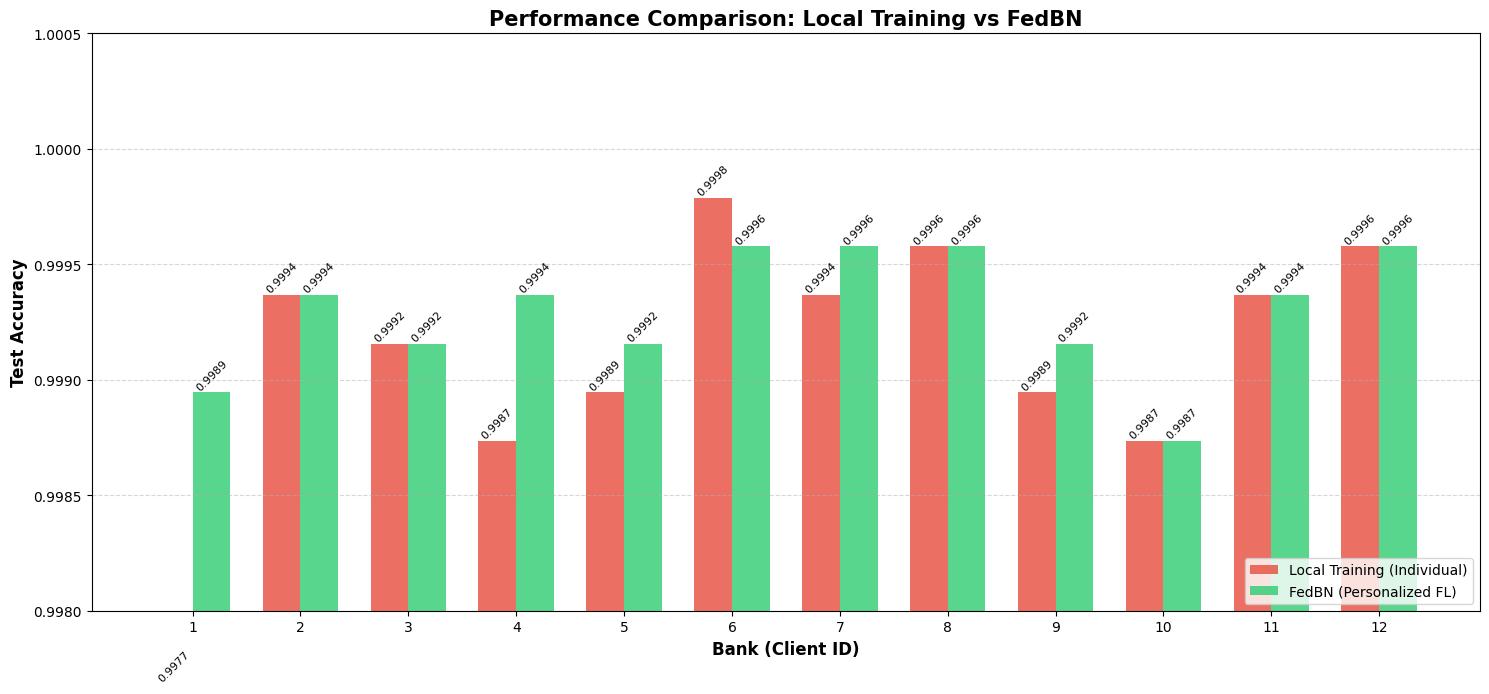

In [12]:
import matplotlib.pyplot as plt
import numpy as np

banks = np.arange(1, NUM_CLIENTS + 1)
width = 0.35

plt.figure(figsize=(15, 7))

# Local (Individual) Accuracy Bars
plt.bar(banks - width/2, local_final_acc, width, label='Local Training (Individual)', color='#e74c3c', alpha=0.8)

# FedBN Accuracy Bars
plt.bar(banks + width/2, current_bn_accs, width, label='FedBN (Personalized FL)', color='#2ecc71', alpha=0.8)

plt.xlabel('Bank (Client ID)', fontsize=12, fontweight='bold')
plt.ylabel('Test Accuracy', fontsize=12, fontweight='bold')
plt.title('Performance Comparison: Local Training vs FedBN', fontsize=15, fontweight='bold')
plt.xticks(banks)

plt.ylim(0.998, 1.0005)

plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.5)

for i in range(len(banks)):
    plt.text(banks[i] - width/2, local_final_acc[i], f'{local_final_acc[i]:.4f}', ha='center', va='bottom', fontsize=8, rotation=45)
    plt.text(banks[i] + width/2, current_bn_accs[i], f'{current_bn_accs[i]:.4f}', ha='center', va='bottom', fontsize=8, rotation=45)

plt.tight_layout()
plt.show()

In [13]:
import gc

# Training Parameters
NUM_ROUNDS = 20
LOCAL_EPOCHS = 1
BATCH_SIZE = 32

fedavg_history = []

print("🚀 Starting Federated Averaging (FedAvg) Training Loop...")

# 1. FedAvg sandaha aluthma Global Model ekak initialize kirima
global_fedavg_model = create_model()

# 2. Banku 12 sandaha aluthma Local Models initialize kirima
fedavg_client_models = [create_model() for _ in range(NUM_CLIENTS)]

# 3. Mulinma hema bankuwakatama global weights laba deem
initial_weights = global_fedavg_model.get_weights()
for model in fedavg_client_models:
    model.set_weights(initial_weights)

for round_num in range(NUM_ROUNDS):
    print(f"--- FedAvg Global Round {round_num+1}/{NUM_ROUNDS} ---")

    all_client_weights = []

    # --- Local Training ---
    for client_id in range(NUM_CLIENTS):
        X_train = clients_final_data[client_id]["X_train"]
        y_train = clients_final_data[client_id]["y_train"]

        local_model = fedavg_client_models[client_id]
        local_model.fit(X_train, y_train, epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE, verbose=0)

        # FedAvg wala api hema weight ekakma gannawa
        all_client_weights.append(local_model.get_weights())

    # --- FedAvg Aggregation (Averaging ALL weights) ---
    # Hema bankuwakagema weights wala wastwa (mean) gannawa
    avg_weights = []
    for weights_list in zip(*all_client_weights):
        avg_weights.append(np.mean(weights_list, axis=0))

    # Global model eka update kirima
    global_fedavg_model.set_weights(avg_weights)

    # --- Syncing back to all clients ---
    # Global model eke aluth weights hema bankuwakatama yawima
    for client_id in range(NUM_CLIENTS):
        fedavg_client_models[client_id].set_weights(avg_weights)

    # --- Evaluation ---
    current_round_accs = []
    for client_id in range(NUM_CLIENTS):
        _, acc = fedavg_client_models[client_id].evaluate(clients_final_data[client_id]["X_test"],
                                                          clients_final_data[client_id]["y_test"], verbose=0)
        current_round_accs.append(acc)

    avg_acc = np.mean(current_round_accs)
    fedavg_history.append(avg_acc)

    print(f"✅ Round {round_num+1} Done. Avg FedAvg Accuracy: {avg_acc:.4f}")
    gc.collect()

print("\n🎯 FedAvg Training Complete!")

🚀 Starting Federated Averaging (FedAvg) Training Loop...
--- FedAvg Global Round 1/20 ---
✅ Round 1 Done. Avg FedAvg Accuracy: 0.9991
--- FedAvg Global Round 2/20 ---
✅ Round 2 Done. Avg FedAvg Accuracy: 0.9994
--- FedAvg Global Round 3/20 ---
✅ Round 3 Done. Avg FedAvg Accuracy: 0.9994
--- FedAvg Global Round 4/20 ---
✅ Round 4 Done. Avg FedAvg Accuracy: 0.9994
--- FedAvg Global Round 5/20 ---
✅ Round 5 Done. Avg FedAvg Accuracy: 0.9993
--- FedAvg Global Round 6/20 ---
✅ Round 6 Done. Avg FedAvg Accuracy: 0.9993
--- FedAvg Global Round 7/20 ---
✅ Round 7 Done. Avg FedAvg Accuracy: 0.9993
--- FedAvg Global Round 8/20 ---
✅ Round 8 Done. Avg FedAvg Accuracy: 0.9993
--- FedAvg Global Round 9/20 ---
✅ Round 9 Done. Avg FedAvg Accuracy: 0.9993
--- FedAvg Global Round 10/20 ---
✅ Round 10 Done. Avg FedAvg Accuracy: 0.9993
--- FedAvg Global Round 11/20 ---
✅ Round 11 Done. Avg FedAvg Accuracy: 0.9993
--- FedAvg Global Round 12/20 ---
✅ Round 12 Done. Avg FedAvg Accuracy: 0.9992
--- FedAvg Gl

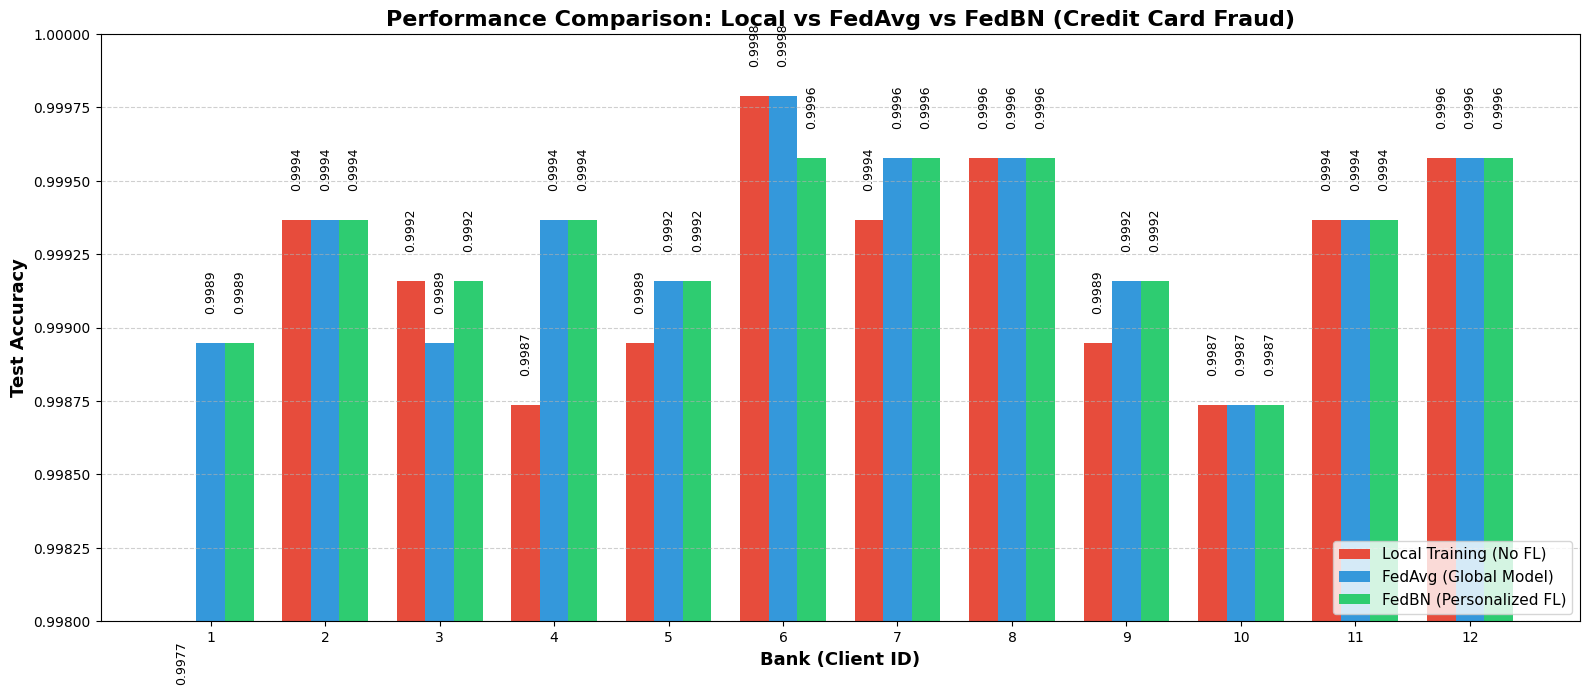

--------------------------------------------------
📊 OVERALL AVERAGE ACCURACY ACROSS ALL 12 BANKS
--------------------------------------------------
🔴 Local Training Avg : 0.99910
🔵 FedAvg Training Avg: 0.99930
🟢 FedBN Training Avg : 0.99930
--------------------------------------------------


In [14]:
import matplotlib.pyplot as plt
import numpy as np

# බැංකු අංක (1-12)
banks = np.arange(1, NUM_CLIENTS + 1)
width = 0.25  # Bar එකක පළල

plt.figure(figsize=(16, 7))

# 1. Local (Individual) Accuracy Bars
plt.bar(banks - width, local_final_acc, width, label='Local Training (No FL)', color='#e74c3c')

# 2. FedAvg Accuracy Bars (current_round_accs වල තියෙන්නේ අන්තිම රවුම් එකේ results)
plt.bar(banks, current_round_accs, width, label='FedAvg (Global Model)', color='#3498db')

# 3. FedBN Accuracy Bars (current_bn_accs වල තියෙන්නේ අන්තිම රවුම් එකේ results)
plt.bar(banks + width, current_bn_accs, width, label='FedBN (Personalized FL)', color='#2ecc71')

# Graph එකේ විස්තර
plt.xlabel('Bank (Client ID)', fontsize=13, fontweight='bold')
plt.ylabel('Test Accuracy', fontsize=13, fontweight='bold')
plt.title('Performance Comparison: Local vs FedAvg vs FedBN (Credit Card Fraud)', fontsize=16, fontweight='bold')
plt.xticks(banks)

# Accuracy අගයන් ඉතා ඉහළ (0.999+) නිසා වෙනස පැහැදිලිව පෙන්වීමට y-axis සීමා කිරීම
plt.ylim(0.9980, 1.0000)

plt.legend(loc='lower right', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# එක් එක් Bar එක උඩින් අගය පෙන්වීම (අගයන් පැටලෙන්නේ නැති වෙන්න 90 degrees හැරෙව්වා)
for i in range(len(banks)):
    plt.text(banks[i] - width, local_final_acc[i] + 0.0001, f'{local_final_acc[i]:.4f}', ha='center', va='bottom', fontsize=9, rotation=90)
    plt.text(banks[i], current_round_accs[i] + 0.0001, f'{current_round_accs[i]:.4f}', ha='center', va='bottom', fontsize=9, rotation=90)
    plt.text(banks[i] + width, current_bn_accs[i] + 0.0001, f'{current_bn_accs[i]:.4f}', ha='center', va='bottom', fontsize=9, rotation=90)

plt.tight_layout()
plt.show()

# සමස්ත සාමාන්‍ය අගයන් (Overall Averages) Print කරමු
print("-" * 50)
print("📊 OVERALL AVERAGE ACCURACY ACROSS ALL 12 BANKS")
print("-" * 50)
print(f"🔴 Local Training Avg : {np.mean(local_final_acc):.5f}")
print(f"🔵 FedAvg Training Avg: {np.mean(current_round_accs):.5f}")
print(f"🟢 FedBN Training Avg : {np.mean(current_bn_accs):.5f}")
print("-" * 50)